# Supply Chain Data Cleaning & Quality Investigation

## Objective

The objective of this notebook is to investigate and clean the DataCo Smart
Supply Chain dataset before performing SQL and Power BI analysis.

The cleaning process focuses on:
- Missing-value investigation
- Column-shift corruption
- Data reconstruction
- Invalid values and data types
- ID integrity
- Location and encoding issues
- Date validation
- Outlier investigation
- Final dataset validation

### Dataset Overview

Raw dataset:
- Rows: 180,519
- Columns: 51
- Business period: 2015–2018

## Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load dataset
import pandas as pd

df = pd.read_csv("Supply_chain.csv", low_memory=False)

print(df.head())

       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Benefit per order  Sales per customer   Delivery Status  \
0          91.250000          314.640015  Advance shipping   
1        -249.089996          311.359985     Late delivery   
2        -247.779999          309.720001  Shipping on time   
3          22.860001          304.809998  Advance shipping   
4         134.210007          298.250000  Advance shipping   

   Late_delivery_risk  Category Id   Category Name Customer City  ...  \
0                   0           73  Sporting Goods        Caguas  ...   
1                   1           73  Sporting Goo

### Initial Dataset Overview

In [4]:
# Initial dataset overview

print("Dataset shape:", df.shape)

print("\nDataset information:")
df.info()

print("\nDescriptive statistics:")
display(df.describe())

Dataset shape: (180519, 51)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 51 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Product Card Id
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,177515.000000
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,670.858305,19.977859,2822.742697,87441.773821,136.818247,0.191344,8.733494,203.081681,177.838666,676.945317
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,353.270301,21.829923,18791.389431,53435.295758,140.492159,0.651141,40.591911,132.100993,123.482223,349.304379
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,0.000000,0.000000,0.000000,1.000000,-2.750000,-2.750000,1.000000,8.290000,-1058.349976,2.000000
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,365.000000,4.800000,0.040000,41587.500000,49.980000,0.080000,1.000000,119.980003,98.959999,403.000000
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,627.000000,13.000000,0.100000,86722.000000,59.990002,0.280000,1.000000,199.919998,159.979996,627.000000
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,1004.000000,28.799999,0.160000,133259.500000,199.990005,0.380000,4.000000,299.950012,245.289993,1004.000000
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,1363.000000,500.000000,171908.000000,180519.000000,1999.989990,5.000000,499.950012,1999.989990,1939.989990,1363.000000


### Data Quality Overview

In [5]:
# Check missing values
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0].sort_values(ascending=False))

# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Shipping Mode                 7585
Order Status                  4581
Product Category Id           4581
Order State                   3004
Product Card Id               3004
shipping date (DateOrders)    3004
Customer Lname                   8
Customer Zipcode                 3
dtype: int64

Duplicate rows: 0


### Investigate suspicious missing values

In [7]:
# Investigate important missing-value patterns

# Rows with missing Product Card Id
missing_product_card = df[df["Product Card Id"].isna()]

print("Rows with missing Product Card Id:", len(missing_product_card))

display(
    missing_product_card[
        ["Product Card Id", "Product Name", "Product Price",
         "Product Category Id", "shipping date (DateOrders)",
         "Shipping Mode", "Order Status"]
    ].head(10)
)

# Rows with missing Shipping Mode
missing_shipping_mode = df[df["Shipping Mode"].isna()]

print("\nRows with missing Shipping Mode:", len(missing_shipping_mode))

display(
    missing_shipping_mode[
        ["Shipping Mode", "shipping date (DateOrders)",
         "Order Status", "Product Card Id"]
    ].head(10)
)

Rows with missing Product Card Id: 3004


,Product Card Id,Product Name,Product Price,Product Category Id,shipping date (DateOrders),Shipping Mode,Order Status
76,NaN,0,05-09-2017 14:23,http://images.acmesports.sports/Perfect+Fitnes...,NaN,NaN,365
101,NaN,0,4/18/2017 14:04,http://images.acmesports.sports/Under+Armour+G...,NaN,NaN,627
104,NaN,0,03-01-2015 20:46,http://images.acmesports.sports/Under+Armour+G...,NaN,NaN,627
114,NaN,0,5/30/2015 1:32,http://images.acmesports.sports/Nike+Men%27s+D...,NaN,NaN,502
125,NaN,0,05-11-2015 15:56,http://images.acmesports.sports/Nike+Men%27s+F...,NaN,NaN,191
126,NaN,0,05-03-2015 11:23,http://images.acmesports.sports/Nike+Men%27s+F...,NaN,NaN,191
334,NaN,0,3/31/2017 23:33,http://images.acmesports.sports/adidas+Men%27s...,NaN,NaN,567
361,NaN,0,05-05-2015 03:41,http://images.acmesports.sports/Titleist+Pro+V...,NaN,NaN,822
675,NaN,0,05-12-2015 09:27,http://images.acmesports.sports/Team+Golf+New+...,NaN,NaN,897
1019,NaN,0,9/29/2016 6:59,http://images.acmesports.sports/Nike+Men%27s+F...,NaN,NaN,191



Rows with missing Shipping Mode: 7585


,Shipping Mode,shipping date (DateOrders),Order Status,Product Card Id
76,NaN,NaN,365,NaN
96,NaN,Standard Class,NaN,24.0
101,NaN,NaN,627,NaN
103,NaN,Standard Class,NaN,24.0
104,NaN,NaN,627,NaN
108,NaN,Standard Class,NaN,24.0
114,NaN,NaN,502,NaN
125,NaN,NaN,191,NaN
126,NaN,NaN,191,NaN
137,NaN,Second Class,NaN,9.0


## Identify Column-Shift Corruption

In [8]:
# Identify suspicious values indicating column-shift corruption

# Check Product Category Id for image URLs
category_url_rows = df[
    df["Product Category Id"].astype(str).str.contains("http", na=False)
]

print("Rows where Product Category Id contains an image URL:",
      len(category_url_rows))

display(
    category_url_rows[
        ["Product Card Id", "Product Category Id",
         "Product Name", "Product Price", "Order Status"]
    ].head(10)
)

# Check Product Name for numeric values
numeric_product_names = pd.to_numeric(
    df["Product Name"], errors="coerce"
).notna()

print("\nRows where Product Name contains numeric values:",
      numeric_product_names.sum())

display(
    df.loc[
        numeric_product_names,
        ["Product Card Id", "Product Name",
         "Product Price", "Product Category Id"]
    ].head(10)
)

Rows where Product Category Id contains an image URL: 3004


,Product Card Id,Product Category Id,Product Name,Product Price,Order Status
76,NaN,http://images.acmesports.sports/Perfect+Fitnes...,0,05-09-2017 14:23,365
101,NaN,http://images.acmesports.sports/Under+Armour+G...,0,4/18/2017 14:04,627
104,NaN,http://images.acmesports.sports/Under+Armour+G...,0,03-01-2015 20:46,627
114,NaN,http://images.acmesports.sports/Nike+Men%27s+D...,0,5/30/2015 1:32,502
125,NaN,http://images.acmesports.sports/Nike+Men%27s+F...,0,05-11-2015 15:56,191
126,NaN,http://images.acmesports.sports/Nike+Men%27s+F...,0,05-03-2015 11:23,191
334,NaN,http://images.acmesports.sports/adidas+Men%27s...,0,3/31/2017 23:33,567
361,NaN,http://images.acmesports.sports/Titleist+Pro+V...,0,05-05-2015 03:41,822
675,NaN,http://images.acmesports.sports/Team+Golf+New+...,0,05-12-2015 09:27,897
1019,NaN,http://images.acmesports.sports/Nike+Men%27s+F...,0,9/29/2016 6:59,191



Rows where Product Name contains numeric values: 7585


,Product Card Id,Product Name,Product Price,Product Category Id
76,NaN,0,05-09-2017 14:23,http://images.acmesports.sports/Perfect+Fitnes...
96,24.0,50,0,NaN
101,NaN,0,4/18/2017 14:04,http://images.acmesports.sports/Under+Armour+G...
103,24.0,50,0,NaN
104,NaN,0,03-01-2015 20:46,http://images.acmesports.sports/Under+Armour+G...
108,24.0,50,0,NaN
114,NaN,0,5/30/2015 1:32,http://images.acmesports.sports/Nike+Men%27s+D...
125,NaN,0,05-11-2015 15:56,http://images.acmesports.sports/Nike+Men%27s+F...
126,NaN,0,05-03-2015 11:23,http://images.acmesports.sports/Nike+Men%27s+F...
137,9.0,99.98999786,0,NaN


## Check Product-Level Relationships

In [9]:
# Check Product Card Id relationships

product_name_check = (
    df.dropna(subset=["Product Card Id", "Product Name"])
      .groupby("Product Card Id")["Product Name"]
      .nunique()
)

print("Product Card Ids linked to multiple Product Names:")
display(product_name_check[product_name_check > 1])

# Check Product Card Id and Product Category Id relationship
product_category_check = (
    df.dropna(subset=["Product Card Id", "Product Category Id"])
      .groupby("Product Card Id")["Product Category Id"]
      .nunique()
)

print("\nProduct Card Ids linked to multiple Product Category Ids:")
display(product_category_check[product_category_check > 1])

Product Card Ids linked to multiple Product Names:


Product Card Id
2.0     2
3.0     3
5.0     2
7.0     2
9.0     2
12.0    3
13.0    3
24.0    2
26.0    4
29.0    3
30.0    2
31.0    3
32.0    2
33.0    3
35.0    7
36.0    3
37.0    4
38.0    4
41.0    3
44.0    4
Name: Product Name, dtype: int64


Product Card Ids linked to multiple Product Category Ids:


Series([], Name: Product Category Id, dtype: int64)

## Investigate Shifted Rows

In [10]:
# Identify rows affected by column shifting

shift_rows = df["Product Category Id"].astype(str).str.contains(
    "http", na=False
)

print("Shifted rows:", shift_rows.sum())

display(
    df.loc[
        shift_rows,
        ["Product Category Id", "Product Name",
         "Product Price", "Order Status", "Shipping Mode"]
    ].head(10)
)

Shifted rows: 3004


,Product Category Id,Product Name,Product Price,Order Status,Shipping Mode
76,http://images.acmesports.sports/Perfect+Fitnes...,0,05-09-2017 14:23,365,NaN
101,http://images.acmesports.sports/Under+Armour+G...,0,4/18/2017 14:04,627,NaN
104,http://images.acmesports.sports/Under+Armour+G...,0,03-01-2015 20:46,627,NaN
114,http://images.acmesports.sports/Nike+Men%27s+D...,0,5/30/2015 1:32,502,NaN
125,http://images.acmesports.sports/Nike+Men%27s+F...,0,05-11-2015 15:56,191,NaN
126,http://images.acmesports.sports/Nike+Men%27s+F...,0,05-03-2015 11:23,191,NaN
334,http://images.acmesports.sports/adidas+Men%27s...,0,3/31/2017 23:33,567,NaN
361,http://images.acmesports.sports/Titleist+Pro+V...,0,05-05-2015 03:41,822,NaN
675,http://images.acmesports.sports/Team+Golf+New+...,0,05-12-2015 09:27,897,NaN
1019,http://images.acmesports.sports/Nike+Men%27s+F...,0,9/29/2016 6:59,191,NaN


## Recover Shifted Product Card Id

In [11]:
# Recover Product Card Id from shifted Order Status values

df_clean = df.copy()

df_clean.loc[shift_rows, "Product Card Id"] = (
    df_clean.loc[shift_rows, "Order Status"]
)

print("Missing Product Card Id after recovery:",
      df_clean["Product Card Id"].isna().sum())

Missing Product Card Id after recovery: 0


C:\Users\Avinash Reddy\AppData\Local\Temp\ipykernel_8028\44475671.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['365' '627' '627' ... '365' '365' '365']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_clean.loc[shift_rows, "Product Card Id"] = (


## Recover Product Category Id

In [12]:
# Create Product Card Id → Product Category Id lookup

category_lookup = (
    df_clean.dropna(subset=["Product Card Id", "Product Category Id"])
    .groupby("Product Card Id")["Product Category Id"]
    .first()
)

# Fill missing Product Category Id values using Product Card Id
missing_category = df_clean["Product Category Id"].isna()

df_clean.loc[missing_category, "Product Category Id"] = (
    df_clean.loc[missing_category, "Product Card Id"]
    .map(category_lookup)
)

print(
    "Missing Product Category Id after recovery:",
    df_clean["Product Category Id"].isna().sum()
)

Missing Product Category Id after recovery: 3926


## Clean Corrupted Product Category Id Values

In [13]:
# Identify and remove image URLs from Product Category Id

category_urls = df_clean["Product Category Id"].astype(str).str.contains(
    "http", na=False
)

print("Image URLs found in Product Category Id:", category_urls.sum())

df_clean.loc[category_urls, "Product Category Id"] = pd.NA

print(
    "Missing Product Category Id after cleaning:",
    df_clean["Product Category Id"].isna().sum()
)

Image URLs found in Product Category Id: 3004
Missing Product Category Id after cleaning: 6930


## Recover Product Name

In [14]:
# Create Product Card Id → Product Name lookup

product_name_lookup = (
    df_clean.dropna(subset=["Product Card Id", "Product Name"])
    .groupby("Product Card Id")["Product Name"]
    .first()
)

# Identify numeric values incorrectly stored in Product Name
numeric_product_name = pd.to_numeric(
    df_clean["Product Name"], errors="coerce"
).notna()

print("Numeric values found in Product Name:", numeric_product_name.sum())

# Treat numeric Product Name values as corrupted
df_clean.loc[numeric_product_name, "Product Name"] = pd.NA

# Recover missing Product Name using Product Card Id
missing_name = df_clean["Product Name"].isna()

df_clean.loc[missing_name, "Product Name"] = (
    df_clean.loc[missing_name, "Product Card Id"]
    .map(product_name_lookup)
)

print(
    "Missing Product Name after recovery:",
    df_clean["Product Name"].isna().sum()
)

Numeric values found in Product Name: 7585
Missing Product Name after recovery: 0


## Investigate Customer-Level Missing Values

In [15]:
# Investigate missing Customer Last Name

missing_lname = df_clean[df_clean["Customer Lname"].isna()]

print("Missing Customer Lname:", len(missing_lname))

display(
    missing_lname[
        ["Customer Id", "Customer Fname", "Customer Lname"]
    ]
)

# Investigate missing Customer Zipcode

missing_zipcode = df_clean[df_clean["Customer Zipcode"].isna()]

print("\nMissing Customer Zipcode:", len(missing_zipcode))

display(
    missing_zipcode[
        ["Customer Id", "Customer City", "Customer State",
         "Customer Country", "Customer Zipcode"]
    ]
)

Missing Customer Lname: 8


,Customer Id,Customer Fname,Customer Lname
41422,17937,May,NaN
50447,14909,Contreras,NaN
86260,18347,Ray,NaN
92621,17354,BlueOneal,NaN
97530,14446,York,NaN
120404,14870,Farley,NaN
166129,17929,Le,NaN
167119,20439,Huff,NaN



Missing Customer Zipcode: 3


,Customer Id,Customer City,Customer State,Customer Country,Customer Zipcode
35704,14577,CA,95758,EE. UU.,NaN
46440,17171,CA,95758,EE. UU.,NaN
82511,14046,CA,91732,EE. UU.,NaN


## Recover Product Price

In [16]:
# Convert Product Price to numeric
df_clean["Product Price_num"] = pd.to_numeric(
    df_clean["Product Price"], errors="coerce"
)

# Create Product Card Id → Product Price lookup
price_lookup = (
    df_clean[
        (df_clean["Product Card Id"].notna()) &
        (df_clean["Product Price_num"] > 0)
    ]
    .groupby("Product Card Id")["Product Price_num"]
    .first()
)

# Recover invalid or missing Product Price values
invalid_price = (
    df_clean["Product Price_num"].isna() |
    (df_clean["Product Price_num"] <= 0)
)

print("Invalid/missing Product Price:", invalid_price.sum())

df_clean.loc[invalid_price, "Product Price_num"] = (
    df_clean.loc[invalid_price, "Product Card Id"]
    .map(price_lookup)
)

print(
    "Unresolved Product Price:",
    df_clean["Product Price_num"].isna().sum()
)

Invalid/missing Product Price: 7585
Unresolved Product Price: 6930


## Recover Product Status

In [17]:
# Keep only valid Product Status values
valid_status = df_clean["Product Status"].isin([0, 1])

print("Invalid Product Status values:", (~valid_status).sum())

# Create Product Card Id → Product Status lookup
status_lookup = (
    df_clean[valid_status & df_clean["Product Card Id"].notna()]
    .groupby("Product Card Id")["Product Status"]
    .first()
)

# Recover invalid or missing Product Status values
invalid_status = ~valid_status

df_clean.loc[invalid_status, "Product Status"] = (
    df_clean.loc[invalid_status, "Product Card Id"]
    .map(status_lookup)
)

print(
    "Unresolved Product Status:",
    df_clean["Product Status"].isna().sum()
)

Invalid Product Status values: 180519
Unresolved Product Status: 180519


## Investigate Shipping Mode and Shipping Date

In [18]:
# Check missing Shipping Mode
print("Missing Shipping Mode:", df_clean["Shipping Mode"].isna().sum())

# Identify Shipping Mode values incorrectly stored in Shipping Date
shipping_modes = [
    "First Class",
    "Second Class",
    "Standard Class",
    "Same Day"
]

shifted_shipping_mode = df_clean["shipping date (DateOrders)"].isin(
    shipping_modes
)

print(
    "Shipping Mode values found inside Shipping Date:",
    shifted_shipping_mode.sum()
)

display(
    df_clean.loc[
        shifted_shipping_mode,
        ["Shipping Mode", "shipping date (DateOrders)"]
    ].head(10)
)

# Recover shifted Shipping Mode values
df_clean.loc[
    shifted_shipping_mode, "Shipping Mode"
] = df_clean.loc[
    shifted_shipping_mode, "shipping date (DateOrders)"
]

print(
    "\nMissing Shipping Mode after recovery:",
    df_clean["Shipping Mode"].isna().sum()
)

Missing Shipping Mode: 7585
Shipping Mode values found inside Shipping Date: 4581


,Shipping Mode,shipping date (DateOrders)
96,NaN,Standard Class
103,NaN,Standard Class
108,NaN,Standard Class
137,NaN,Second Class
242,NaN,Standard Class
252,NaN,Standard Class
253,NaN,Standard Class
323,NaN,Standard Class
337,NaN,Standard Class
352,NaN,Standard Class



Missing Shipping Mode after recovery: 3004


## Clean and Validate Shipping Date

In [20]:
# Convert Shipping Date to datetime
df_clean["shipping date (DateOrders)"] = pd.to_datetime(
    df_clean["shipping date (DateOrders)"],
    errors="coerce"
)

# Convert Excel serial dates where applicable
shipping_numeric = pd.to_numeric(
    df_clean["shipping date (DateOrders)"],
    errors="coerce"
)

excel_dates = (
    df_clean["shipping date (DateOrders)"].isna()
    & shipping_numeric.notna()
)

df_clean.loc[excel_dates, "shipping date (DateOrders)"] = pd.to_datetime(
    shipping_numeric[excel_dates],
    unit="D",
    origin="1899-12-30",
    errors="coerce"
)

print(
    "Missing Shipping Date after conversion:",
    df_clean["shipping date (DateOrders)"].isna().sum()
)

Missing Shipping Date after conversion: 75937


## Reconstruct Recoverable Shipping Dates

In [22]:
# Reconstruct only recoverable missing Shipping Dates

order_date = pd.to_datetime(
    df_clean["order date (DateOrders)"],
    format="mixed",
    errors="coerce"
)

shipping_days = pd.to_numeric(
    df_clean["Days for shipping (real)"],
    errors="coerce"
)

missing_shipping_date = (
    df_clean["shipping date (DateOrders)"].isna()
)

recoverable_shipping_date = (
    missing_shipping_date
    & order_date.notna()
    & shipping_days.notna()
)

df_clean.loc[
    recoverable_shipping_date,
    "shipping date (DateOrders)"
] = (
    order_date[recoverable_shipping_date]
    + pd.to_timedelta(
        shipping_days[recoverable_shipping_date],
        unit="D"
    )
)

print(
    "Shipping Dates reconstructed:",
    recoverable_shipping_date.sum()
)

print(
    "Remaining missing Shipping Dates:",
    df_clean["shipping date (DateOrders)"].isna().sum()
)

Shipping Dates reconstructed: 55037
Remaining missing Shipping Dates: 0


## Recover Order Status

In [24]:
# Define valid Order Status values
valid_order_status = [
    "COMPLETE",
    "PENDING_PAYMENT",
    "PROCESSING",
    "PENDING",
    "CLOSED",
    "ON_HOLD",
    "SUSPECTED_FRAUD",
    "CANCELED",
    "PAYMENT_REVIEW"
]

# Identify invalid Order Status values
invalid_order_status = ~df_clean["Order Status"].isin(
    valid_order_status
)

print("Invalid Order Status values:", invalid_order_status.sum())

# Replace invalid values with missing
df_clean.loc[invalid_order_status, "Order Status"] = pd.NA

# Create Order Id → Order Status lookup
order_status_lookup = (
    df_clean.dropna(subset=["Order Id", "Order Status"])
    .groupby("Order Id")["Order Status"]
    .first()
)

# Recover missing Order Status
missing_order_status = df_clean["Order Status"].isna()

df_clean.loc[missing_order_status, "Order Status"] = (
    df_clean.loc[missing_order_status, "Order Id"]
    .map(order_status_lookup)
)

print(
    "Remaining missing Order Status:",
    df_clean["Order Status"].isna().sum()
)

Invalid Order Status values: 7585
Remaining missing Order Status: 4171


## Recover Order State

In [25]:
# Check missing Order State
print("Missing Order State:", df_clean["Order State"].isna().sum())

# Create a safe Order Country + Order City → Order State mapping
state_lookup = (
    df_clean.dropna(
        subset=["Order Country", "Order City", "Order State"]
    )
    .groupby(["Order Country", "Order City"])["Order State"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)
)

# Keep only country-city combinations with a single known state
state_counts = (
    df_clean.dropna(
        subset=["Order Country", "Order City", "Order State"]
    )
    .groupby(["Order Country", "Order City"])["Order State"]
    .nunique()
)

safe_state_lookup = state_lookup[state_counts == 1]

# Recover missing Order State
missing_state = df_clean["Order State"].isna()

df_clean.loc[missing_state, "Order State"] = [
    safe_state_lookup.get(
        (country, city), pd.NA
    )
    for country, city in zip(
        df_clean.loc[missing_state, "Order Country"],
        df_clean.loc[missing_state, "Order City"]
    )
]

print(
    "Remaining missing Order State:",
    df_clean["Order State"].isna().sum()
)

Missing Order State: 3004
Remaining missing Order State: 3004


## Standardize Column Names

In [26]:
# Rename columns to snake_case

df_clean.rename(columns={
    "Type": "type",
    "Days for shipping (real)": "days_for_shipping_real",
    "Days for shipment (scheduled)": "days_for_shipment_scheduled",
    "Benefit per order": "benefit_per_order",
    "Sales per customer": "sales_per_customer",
    "Delivery Status": "delivery_status",
    "Late_delivery_risk": "late_delivery_risk",
    "Category Id": "category_id",
    "Category Name": "category_name",
    "Customer City": "customer_city",
    "Customer Country": "customer_country",
    "Customer Email": "customer_email",
    "Customer Fname": "customer_first_name",
    "Customer Id": "customer_id",
    "Customer Lname": "customer_last_name",
    "Customer Password": "customer_password",
    "Customer Segment": "customer_segment",
    "Customer State": "customer_state",
    "Customer Street": "customer_street",
    "Customer Zipcode": "customer_zipcode",
    "Department Id": "department_id",
    "Department Name": "department_name",
    "Latitude": "latitude",
    "Longitude": "longitude",
    "Market": "market",
    "Order City": "order_city",
    "Order Country": "order_country",
    "Order Customer Id": "order_customer_id",
    "order date (DateOrders)": "order_date",
    "Order Id": "order_id",
    "Order Item Cardprod Id": "order_item_product_id",
    "Order Item Discount": "order_item_discount",
    "Order Item Discount Rate": "order_item_discount_rate",
    "Order Item Id": "order_item_id",
    "Order Item Product Price": "order_item_product_price",
    "Order Item Profit Ratio": "order_item_profit_ratio",
    "Order Item Quantity": "order_item_quantity",
    "Sales": "sales",
    "Order Item Total": "order_item_total",
    "Order Profit Per Order": "order_profit_per_order",
    "Order Region": "order_region",
    "Order State": "order_state",
    "Order Status": "order_status",
    "Product Card Id": "product_card_id",
    "Product Category Id": "product_category_id",
    "Product Image": "product_image",
    "Product Name": "product_name",
    "Product Price": "product_price",
    "Product Status": "product_status",
    "shipping date (DateOrders)": "shipping_date",
    "Shipping Mode": "shipping_mode"
}, inplace=True)

print("Dataset shape:", df_clean.shape)
print("Number of columns:", len(df_clean.columns))

Dataset shape: (180519, 52)
Number of columns: 52


## Clean Numeric and Temporary Columns

In [28]:
# Remove temporary columns used during investigation
df_clean.drop(
    columns=["Product Price_num", "Product_Name_Corrupted"],
    errors="ignore",
    inplace=True
)

# Convert numeric columns first
numeric_columns = [
    "days_for_shipping_real",
    "days_for_shipment_scheduled",
    "benefit_per_order",
    "sales_per_customer",
    "late_delivery_risk",
    "order_item_discount",
    "order_item_discount_rate",
    "order_item_product_price",
    "order_item_profit_ratio",
    "order_item_quantity",
    "sales",
    "order_item_total",
    "product_price"
]

for col in numeric_columns:
    df_clean[col] = pd.to_numeric(
        df_clean[col], errors="coerce"
    )

# Convert ID columns only when values are whole numbers
id_columns = [
    "category_id",
    "customer_id",
    "department_id",
    "order_id",
    "order_item_product_id",
    "product_card_id",
    "product_category_id"
]

for col in id_columns:
    values = pd.to_numeric(df_clean[col], errors="coerce")

    whole_number = (
        values.isna() |
        (values % 1 == 0)
    )

    df_clean.loc[~whole_number, col] = pd.NA

    df_clean[col] = values.astype("Int64")

print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))

Rows: 180519
Columns: 51


## Clean Discount Rate

In [29]:
# Validate Order Item Discount Rate

invalid_discount_rate = (
    df_clean["order_item_discount_rate"] > 1
)

print(
    "Invalid Discount Rate values:",
    invalid_discount_rate.sum()
)

# Values greater than 1 are invalid rates
df_clean.loc[
    invalid_discount_rate,
    "order_item_discount_rate"
] = pd.NA

print(
    "Missing Discount Rate after cleaning:",
    df_clean["order_item_discount_rate"].isna().sum()
)

Invalid Discount Rate values: 6145
Missing Discount Rate after cleaning: 6145


## Clean Order Item Quantity

In [30]:
# Validate Order Item Quantity

invalid_quantity = (
    df_clean["order_item_quantity"] > 10
)

print(
    "Invalid Quantity values:",
    invalid_quantity.sum()
)

# Values above 10 were identified as invalid
df_clean.loc[
    invalid_quantity,
    "order_item_quantity"
] = pd.NA

print(
    "Missing Quantity after cleaning:",
    df_clean["order_item_quantity"].isna().sum()
)

Invalid Quantity values: 6142
Missing Quantity after cleaning: 6142


## Validate Order Item Product Price

In [31]:
# Validate Order Item Product Price

invalid_product_price = (
    df_clean["order_item_product_price"] <= 1
)

print(
    "Invalid Product Price values:",
    invalid_product_price.sum()
)

# Values <= 1 were identified as invalid
df_clean.loc[
    invalid_product_price,
    "order_item_product_price"
] = pd.NA

print(
    "Missing Product Price after cleaning:",
    df_clean["order_item_product_price"].isna().sum()
)

Invalid Product Price values: 6145
Missing Product Price after cleaning: 6145


## Validate Order Item Id

In [32]:
# Check for invalid / non-integer Order Item Id values

order_item_id_numeric = pd.to_numeric(
    df_clean["order_item_id"],
    errors="coerce"
)

invalid_order_item_id = (
    order_item_id_numeric.isna()
    | (order_item_id_numeric % 1 != 0)
)

print(
    "Invalid Order Item Id values:",
    invalid_order_item_id.sum()
)

display(
    df_clean.loc[
        invalid_order_item_id,
        ["order_item_id", "order_item_product_price", "product_card_id"]
    ].head(10)
)

Invalid Order Item Id values: 5268


,order_item_id,order_item_product_price,product_card_id
76,59.990002,NaN,365
101,39.990002,NaN,627
104,39.990002,NaN,627
125,99.989998,NaN,191
126,99.989998,NaN,191
242,129.990005,NaN,18
252,129.990005,NaN,18
337,39.990002,NaN,29
361,47.990002,NaN,822
460,99.989998,NaN,9


## Repair Corrupted Order Item Ids

In [33]:
# Preserve the original Order Item Id
df_clean["original_order_item_id"] = df_clean["order_item_id"]

# Convert valid whole-number IDs to integers
order_item_id_numeric = pd.to_numeric(
    df_clean["order_item_id"],
    errors="coerce"
)

valid_order_item_id = (
    order_item_id_numeric.notna()
    & (order_item_id_numeric % 1 == 0)
)

df_clean.loc[valid_order_item_id, "order_item_id"] = (
    order_item_id_numeric[valid_order_item_id].astype("Int64")
)

# Identify corrupted IDs
invalid_order_item_id = ~valid_order_item_id

print(
    "Corrupted Order Item Id values:",
    invalid_order_item_id.sum()
)

Corrupted Order Item Id values: 5268


## Assign Surrogate Order Item Ids

In [34]:
# Assign surrogate IDs to corrupted Order Item Id values

surrogate_count = invalid_order_item_id.sum()

df_clean.loc[invalid_order_item_id, "order_item_id"] = [
    f"SURR_{i}"
    for i in range(1, surrogate_count + 1)
]

print("Surrogate IDs assigned:", surrogate_count)

print(
    "Unique Order Item Ids:",
    df_clean["order_item_id"].nunique()
)

Surrogate IDs assigned: 5268
Unique Order Item Ids: 179645


C:\Users\Avinash Reddy\AppData\Local\Temp\ipykernel_8028\3253079796.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['SURR_1', 'SURR_2', 'SURR_3', 'SURR_4', 'SURR_5', 'SURR_6', 'SURR_7', 'SURR_8', 'SURR_9', 'SURR_10', 'SURR_11', 'SURR_12', 'SURR_13', 'SURR_14', 'SURR_15', 'SURR_16', 'SURR_17', 'SURR_18', 'SURR_19', 'SURR_20', 'SURR_21', 'SURR_22', 'SURR_23', 'SURR_24', 'SURR_25', 'SURR_26', 'SURR_27', 'SURR_28', 'SURR_29', 'SURR_30', 'SURR_31', 'SURR_32', 'SURR_33', 'SURR_34', 'SURR_35', 'SURR_36', 'SURR_37', 'SURR_38', 'SURR_39', 'SURR_40', 'SURR_41', 'SURR_42', 'SURR_43', 'SURR_44', 'SURR_45', 'SURR_46', 'SURR_47', 'SURR_48', 'SURR_49', 'SURR_50', 'SURR_51', 'SURR_52', 'SURR_53', 'SURR_54', 'SURR_55', 'SURR_56', 'SURR_57', 'SURR_58', 'SURR_59', 'SURR_60', 'SURR_61', 'SURR_62', 'SURR_63', 'SURR_64', 'SURR_65', 'SURR_66', 'SURR_67', 'SURR_68', 'SURR_69', 'SURR_70', 'SURR_71', 'SURR_72', 'SURR_73', 'S

## Clean Location Fields

In [35]:
# Remove unwanted whitespace from location fields

location_columns = [
    "order_region",
    "order_country",
    "order_state",
    "order_city",
    "customer_country",
    "customer_state",
    "customer_city"
]

for col in location_columns:
    df_clean[col] = df_clean[col].astype("string").str.strip()

# Check missing values in location fields
location_missing = df_clean[location_columns].isna().sum()

print("Missing values in location fields:")
display(location_missing[location_missing > 0])

Missing values in location fields:


order_state    3004
dtype: int64

## Clean Location Fields

In [36]:
# Clean location fields

location_columns = [
    "order_region", "order_country", "order_state", "order_city",
    "customer_country", "customer_state", "customer_city"
]

for col in location_columns:
    df_clean[col] = df_clean[col].astype("string").str.strip()

# Fix common encoding issues in locations
location_fixes = {
    "Panam?": "Panamá",
    "Bogot?": "Bogotá",
    "S? Paulo": "São Paulo",
    "Chiriqu?": "Chiriquí",
    "San Luis Potos?": "San Luis Potosí",
    "Estel?": "Estelí",
    "Cear?": "Ceará",
    "Amap?": "Amapá",
    "Paran?": "Paraná",
    "Bah?": "Bahia",
    "Goi?": "Goiás",
    "Antioqu?": "Antioquia",
    "Potos?": "Potosí",
    "Catalu?": "Cataluña",
    "Rond?ia": "Rondônia",
    "Choc?": "Chocó",
    "Paysand?": "Paysandú"
}

for col in ["order_region", "order_state", "order_city"]:
    df_clean[col] = df_clean[col].replace(location_fixes)

# Targeted country fixes
country_fixes = {
    "M?ico": "México",
    "Espa?": "España",
    "Rep?lica Dominicana": "República Dominicana",
    "Turqu?": "Turquía",
    "Panam?": "Panamá",
    "Pa?es Bajos": "Países Bajos",
    "Ir?": "Irán",
    "Per?": "Perú",
    "Pakist?": "Pakistán",
    "Jap?": "Japón",
    "B?gica": "Bélgica",
    "Hait?": "Haití",
    "Banglad?": "Bangladés",
    "Camer?": "Camerún",
    "Sud?": "Sudán",
    "Kazajist?": "Kazajistán",
    "Hungr?": "Hungría",
    "Rep?lica Checa": "República Checa",
    "Afganist?": "Afganistán",
    "Uzbekist?": "Uzbekistán",
    "Kirguist?": "Kirguistán",
    "Ben?": "Benín",
    "Taiw?": "Taiwán",
    "Etiop?": "Etiopía",
    "L?ano": "Líbano",
    "Om?": "Omán"
}

df_clean["order_country"] = df_clean["order_country"].replace(country_fixes)

# Normalize Indian state names
india_state_fixes = {
    "Guyarat": "Gujarat",
    "Bengala Occidental": "West Bengal",
    "Punyab": "Punjab",
    "Jammu y Cachemira": "Jammu and Kashmir"
}

df_clean["order_state"] = df_clean["order_state"].replace(
    india_state_fixes
)

print("Location cleaning completed.")

Location cleaning completed.


## Validate Numeric Fields

In [38]:
# Validate important numeric fields

# Numeric conversions
numeric_columns = [
    "benefit_per_order",
    "sales_per_customer",
    "order_item_discount",
    "order_item_discount_rate",
    "order_item_product_price",
    "order_item_profit_ratio",
    "order_item_quantity",
    "sales",
    "order_item_total",
    "product_price"
]

for col in numeric_columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Validate Product Category Id
df_clean["product_category_id"] = pd.to_numeric(
    df_clean["product_category_id"], errors="coerce"
).astype("Int64")

# Validate Product Status
df_clean["product_status"] = pd.to_numeric(
    df_clean["product_status"], errors="coerce"
)

print("Numeric validation completed.")

display(
    df_clean[
        numeric_columns
    ].isna().sum().sort_values(ascending=False)
)

Numeric validation completed.


order_item_discount_rate    6145
order_item_product_price    6145
order_item_quantity         6142
product_price               3004
benefit_per_order              0
sales_per_customer             0
order_item_discount            0
order_item_profit_ratio        0
sales                          0
order_item_total               0
dtype: int64

## Validate Dates

In [39]:
# Validate date fields

df_clean["order_date"] = pd.to_datetime(
    df_clean["order_date"],
    errors="coerce"
)

df_clean["shipping_date"] = pd.to_datetime(
    df_clean["shipping_date"],
    errors="coerce"
)

# Keep dates within the business period 2015–2018
for col in ["order_date", "shipping_date"]:
    invalid_dates = ~df_clean[col].dt.year.between(
        2015, 2018
    )
    df_clean.loc[invalid_dates, col] = pd.NaT

print("Date validation completed.")
print("Order Date range:",
      df_clean["order_date"].min(),
      "to",
      df_clean["order_date"].max())

Date validation completed.
Order Date range: 2015-01-13 00:20:00 to 2018-01-31 23:38:00


## Analyze Numeric Distributions and Outliers

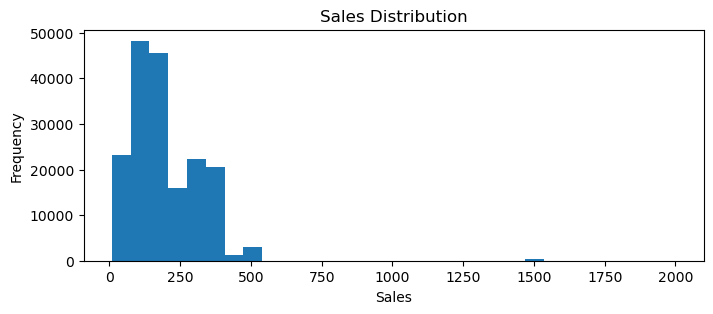

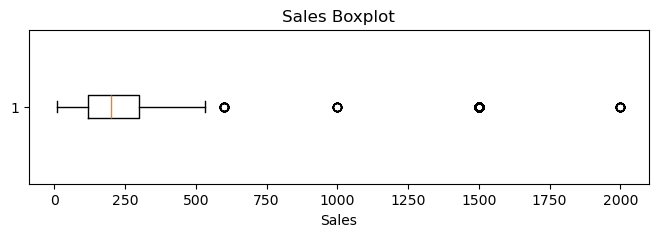

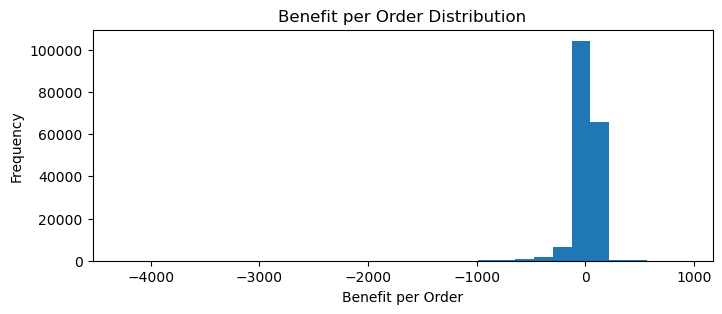

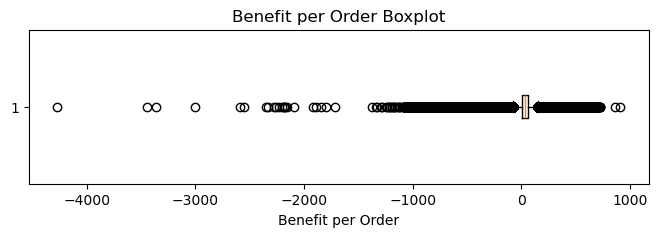

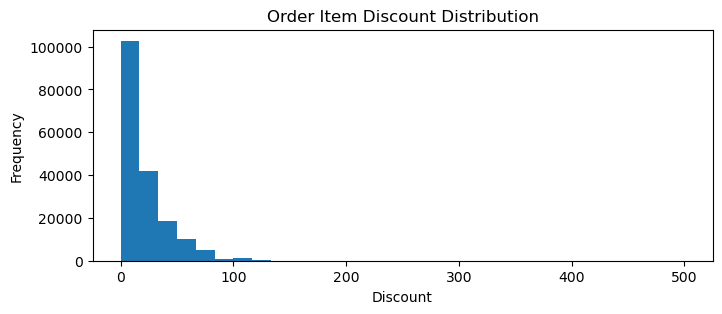

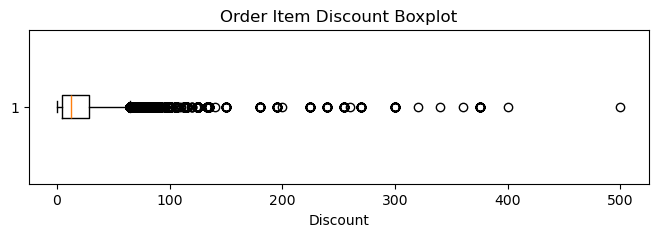

In [42]:
import matplotlib.pyplot as plt

# Sales
plt.figure(figsize=(8, 3))
plt.hist(df_clean["sales"].dropna(), bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 2))
plt.boxplot(df_clean["sales"].dropna(), vert=False)
plt.title("Sales Boxplot")
plt.xlabel("Sales")
plt.show()


# Benefit per Order
plt.figure(figsize=(8, 3))
plt.hist(df_clean["benefit_per_order"].dropna(), bins=30)
plt.title("Benefit per Order Distribution")
plt.xlabel("Benefit per Order")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 2))
plt.boxplot(df_clean["benefit_per_order"].dropna(), vert=False)
plt.title("Benefit per Order Boxplot")
plt.xlabel("Benefit per Order")
plt.show()


# Order Item Discount
plt.figure(figsize=(8, 3))
plt.hist(df_clean["order_item_discount"].dropna(), bins=30)
plt.title("Order Item Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 2))
plt.boxplot(df_clean["order_item_discount"].dropna(), vert=False)
plt.title("Order Item Discount Boxplot")
plt.xlabel("Discount")
plt.show()

## Repair Product Status and Order Date

In [44]:
# Repair Product Status using Product Card Id

status_lookup = (
    df.dropna(subset=["Product Card Id", "Product Status"])
      .assign(
          Product_Status_Num=pd.to_numeric(
              df["Product Status"], errors="coerce"
          )
      )
)

status_lookup = (
    status_lookup[
        status_lookup["Product_Status_Num"].isin([0, 1])
    ]
    .groupby("Product Card Id")["Product_Status_Num"]
    .first()
)

df_clean["product_status"] = (
    df_clean["product_card_id"].map(status_lookup)
)

print(
    "Missing Product Status:",
    df_clean["product_status"].isna().sum()
)


# Restore Order Date from the original dataset
df_clean["order_date"] = pd.to_datetime(
    df["order date (DateOrders)"],
    format="mixed",
    errors="coerce"
)

print(
    "Missing Order Date:",
    df_clean["order_date"].isna().sum()
)

Missing Product Status: 3926
Missing Order Date: 0


## Final Numeric Corrections

In [45]:
# Recover Order Item Product Id using Product Card Id

product_id_lookup = (
    df_clean.dropna(subset=["product_card_id"])
    .groupby("product_card_id")["product_card_id"]
    .first()
)

missing_product_id = df_clean["order_item_product_id"].isna()

df_clean.loc[missing_product_id, "order_item_product_id"] = (
    df_clean.loc[missing_product_id, "product_card_id"]
)

# Convert Product IDs to nullable integers
df_clean["order_item_product_id"] = pd.to_numeric(
    df_clean["order_item_product_id"],
    errors="coerce"
).astype("Int64")

print(
    "Missing Order Item Product Id:",
    df_clean["order_item_product_id"].isna().sum()
)

# Remove temporary reference column
df_clean.drop(
    columns=["original_order_item_id"],
    errors="ignore",
    inplace=True
)

print("Final column count:", len(df_clean.columns))

Missing Order Item Product Id: 0
Final column count: 51


## Final Data Validation

In [47]:
# Final validation

print("Final shape:", df_clean.shape)
print("Duplicate rows:", df_clean.duplicated().sum())

print("\nMissing values:")
display(
    df_clean.isna().sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
)

print("\nData types:")
df_clean.info()

Final shape: (180519, 51)
Duplicate rows: 0

Missing values:


product_category_id         6930
order_item_discount_rate    6145
order_item_product_price    6145
order_item_quantity         6142
shipping_date               6042
order_status                4171
product_status              3926
order_state                 3004
product_price               3004
shipping_mode               3004
customer_last_name             8
customer_zipcode               3
dtype: int64


Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 51 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   type                         180519 non-null  object        
 1   days_for_shipping_real       180519 non-null  int64         
 2   days_for_shipment_scheduled  180519 non-null  int64         
 3   benefit_per_order            180519 non-null  float64       
 4   sales_per_customer           180519 non-null  float64       
 5   delivery_status              180519 non-null  object        
 6   late_delivery_risk           180519 non-null  int64         
 7   category_id                  180519 non-null  Int64         
 8   category_name                180519 non-null  object        
 9   customer_city                180519 non-null  string        
 10  customer_country             180519 non-null  string        
 11  customer_emai

## Export Cleaned Dataset

In [48]:
df_clean.to_csv(
    "Supply_Chain_Cleaned.csv",
    index=False,
    encoding="utf-8",
    quoting=1
)

import csv

with open("Supply_Chain_Cleaned.csv", encoding="utf-8") as f:
    reader = csv.reader(f)
    for i, row in enumerate(reader):
        if len(row) != 52:
            print("Problem row:", i, len(row))
            break


Problem row: 0 51
